[*********************100%***********************]  1 of 1 completed


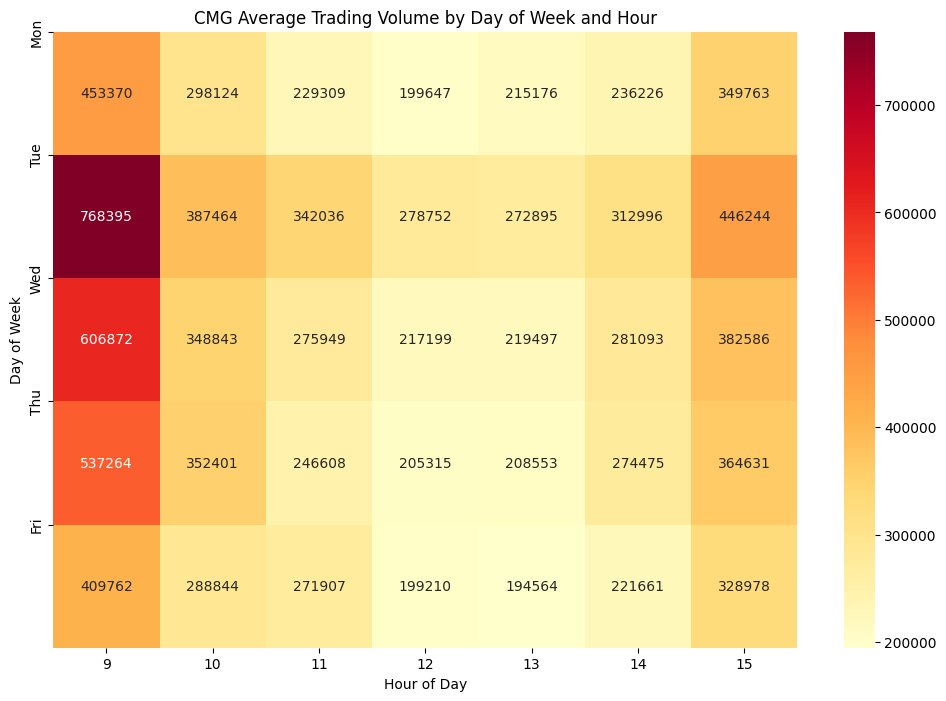

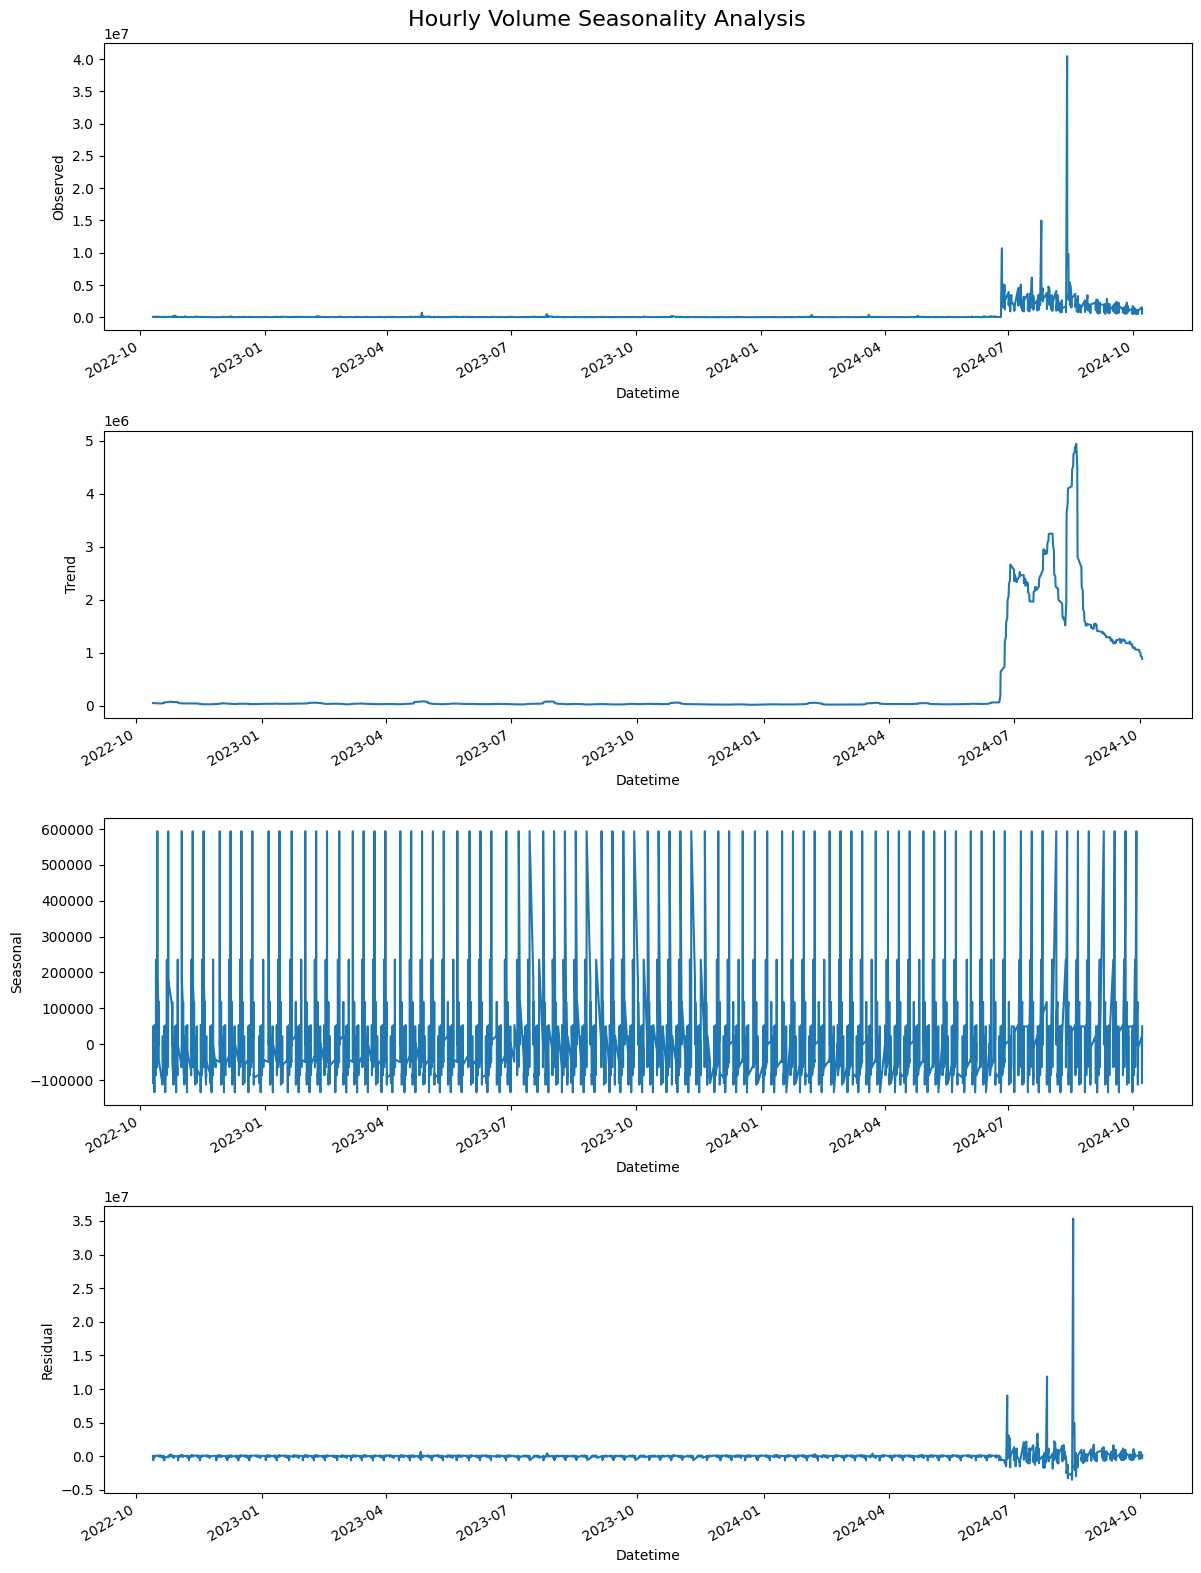

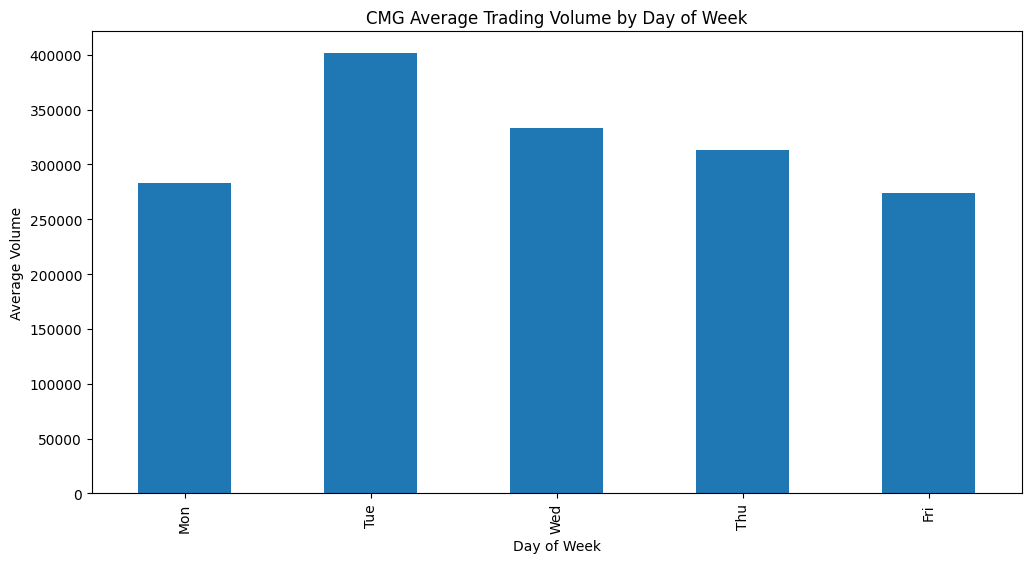

Intraday seasonality analysis complete.


In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Download intraday data
ticker = "CMG"
data = yf.download(ticker, period="max", interval="1h")

# Extract volume data
hourly_volume = data['Volume']

# Calculate average volume by day of week and hour
volume_by_day_hour = hourly_volume.groupby([hourly_volume.index.dayofweek, hourly_volume.index.hour]).mean().unstack()

# Plot heatmap of average volume by day of week and hour
plt.figure(figsize=(12, 8))
sns.heatmap(volume_by_day_hour, cmap="YlOrRd", annot=True, fmt=".0f")
plt.title(f'{ticker} Average Trading Volume by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.yticks(range(5), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
plt.show()

# Function to plot seasonal decomposition
def plot_seasonal_decompose(series, title):
    result = seasonal_decompose(series, model='additive', period=7*6)  # Assuming 6 trading hours per day
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16))
    fig.suptitle(f'{title} Seasonality Analysis', fontsize=16)
    
    result.observed.plot(ax=ax1)
    ax1.set_ylabel('Observed')
    result.trend.plot(ax=ax2)
    ax2.set_ylabel('Trend')
    result.seasonal.plot(ax=ax3)
    ax3.set_ylabel('Seasonal')
    result.resid.plot(ax=ax4)
    ax4.set_ylabel('Residual')
    
    plt.tight_layout()
    plt.show()

# Perform seasonal decomposition
plot_seasonal_decompose(hourly_volume, 'Hourly Volume')

# Calculate average volume by day of week
daily_avg = hourly_volume.groupby(hourly_volume.index.dayofweek).mean()
daily_avg = daily_avg.reindex(range(5), fill_value=0)

# Plot average volume by day of week
plt.figure(figsize=(12, 6))
daily_avg.plot(kind='bar')
plt.title(f'{ticker} Average Trading Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Volume')
plt.xticks(range(5), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
plt.show()

print("Intraday seasonality analysis complete.")
